In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    brier_score_loss,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

In [2]:
# 1. Simulación de cohorte clínica sintética (N = 6,000 pacientes)
np.random.seed(42)
n_samples = 6000

edad = np.random.normal(62, 12, n_samples).clip(18, 95).round()
presion_arterial_media = np.random.normal(75, 14, n_samples)
lactato = np.random.exponential(1.8, n_samples)
creatinina = np.random.lognormal(0.2, 0.4, n_samples)

# Probabilidad latente no lineal de fallo hemodinámico
log_odds = (
    -4.5 
    + 0.03 * edad 
    - 0.04 * presion_arterial_media 
    + 0.65 * lactato 
    + 0.50 * creatinina
)
prob_real = 1 / (1 + np.exp(-log_odds))
evento_adverso = np.random.binomial(1, prob_real)

df_salud = pd.DataFrame({
    'edad': edad,
    'pam': presion_arterial_media,
    'lactato': lactato,
    'creatinina': creatinina,
    'evento': evento_adverso
})

df_salud.head()

,edad,pam,lactato,creatinina,evento
0,68.0,59.402861,0.848297,0.874261,0
1,60.0,66.166968,1.551492,0.641422,0
2,70.0,61.811157,1.039367,1.054580,0
3,80.0,67.328059,0.031497,1.913986,0
4,59.0,72.001896,9.208113,1.587855,1


In [3]:
X = df_salud.drop(columns='evento')
y = df_salud['evento']

# 2. Partición de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

In [4]:
from sklearn.model_selection import RandomizedSearchCV

# 3. Entrenamiento del clasificador base
modelo_base = HistGradientBoostingClassifier(
    random_state=42,
    class_weight='balanced',
    )

randon_search = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions={
        'learning_rate': [0.01, 0.05, 0.1],
        'max_iter': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'min_samples_leaf': [20, 50, 100]
    },
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

randon_search.fit(X_train, y_train)

# Mètricas de desempeño del modelo base

print("Prevalencia real de eventos:", y_test.mean())

probs_raw = randon_search.best_estimator_.predict_proba(X_test)[:, 1]
print("AUC-ROC del modelo base:", roc_auc_score(y_test, probs_raw))
print("Brier Score del modelo base:", brier_score_loss(y_test, probs_raw))

Prevalencia real de eventos: 0.051666666666666666
AUC-ROC del modelo base: 0.8604512727478881
Brier Score del modelo base: 0.11835396240379466


In [5]:
classification_report_base = classification_report(y_test, randon_search.best_estimator_.predict(X_test), output_dict=True)
print("=== REPORTE DE CLASIFICACIÓN (MODELO BASE) ===")
print(pd.DataFrame(classification_report_base).transpose())

=== REPORTE DE CLASIFICACIÓN (MODELO BASE) ===
              precision    recall  f1-score      support
0              0.981321  0.861746  0.917654  1707.000000
1              0.215947  0.698925  0.329949    93.000000
accuracy       0.853333  0.853333  0.853333     0.853333
macro avg      0.598634  0.780335  0.623802  1800.000000
weighted avg   0.941777  0.853333  0.887290  1800.000000


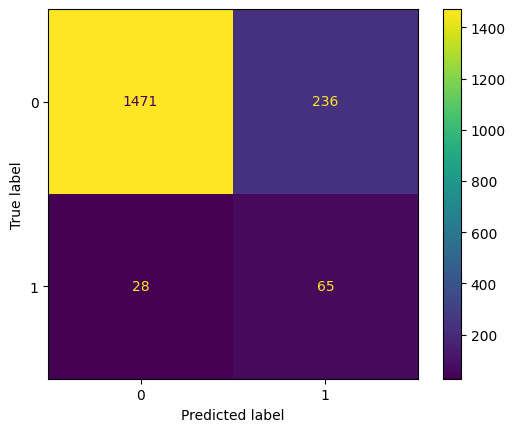

In [6]:
ConfusionMatrixDisplay.from_estimator(randon_search.best_estimator_, X_test, y_test)

In [7]:
# 4. Calibración sigmoidea (Platt Scaling)
# Enfoque con validación interna para no sesgar probabilidades
modelo_calibrado = CalibratedClassifierCV(estimator=randon_search.best_estimator_, cv=5, method='sigmoid')
modelo_calibrado.fit(X_train, y_train)


probs_cal = modelo_calibrado.predict_proba(X_test)[:, 1]

# 5. Evaluación: Discriminación vs. Calibración

print("=== EVALUACIÓN EN SALUD ===")
print(f"Prevalencia real de eventos: {y_test.mean():.2%}")
print(f"ROC-AUC (Base):       {roc_auc_score(y_test, probs_raw):.4f}")
print(f"ROC-AUC (Calibrado):  {roc_auc_score(y_test, probs_cal):.4f}")
print(f"Brier Score (Base):      {brier_score_loss(y_test, probs_raw):.4f}  (menor es mejor)")
print(f"Brier Score (Calibrado): {brier_score_loss(y_test, probs_cal):.4f}  (menor es mejor)")

=== EVALUACIÓN EN SALUD ===
Prevalencia real de eventos: 5.17%
ROC-AUC (Base):       0.8605
ROC-AUC (Calibrado):  0.8633
Brier Score (Base):      0.1184  (menor es mejor)
Brier Score (Calibrado): 0.0385  (menor es mejor)


In [8]:
classification_report_calibrado = classification_report(y_test, modelo_calibrado.predict(X_test), output_dict=True)
print("=== REPORTE DE CLASIFICACIÓN (MODELO CALIBRADO) ===")
print(pd.DataFrame(classification_report_calibrado).transpose())

=== REPORTE DE CLASIFICACIÓN (MODELO CALIBRADO) ===
              precision    recall  f1-score      support
0              0.960272  0.991213  0.975497  1707.000000
1              0.605263  0.247312  0.351145    93.000000
accuracy       0.952778  0.952778  0.952778     0.952778
macro avg      0.782768  0.619262  0.663321  1800.000000
weighted avg   0.941930  0.952778  0.943239  1800.000000


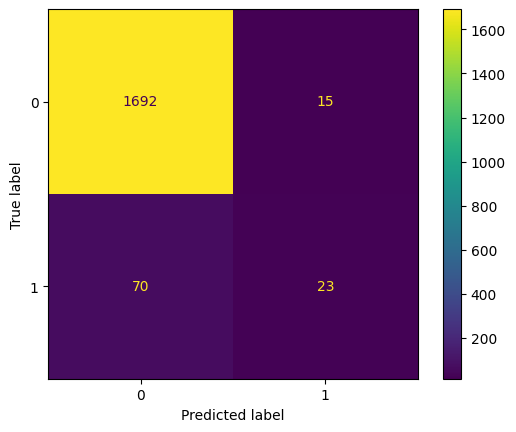

In [9]:
ConfusionMatrixDisplay.from_estimator(modelo_calibrado, X_test, y_test)

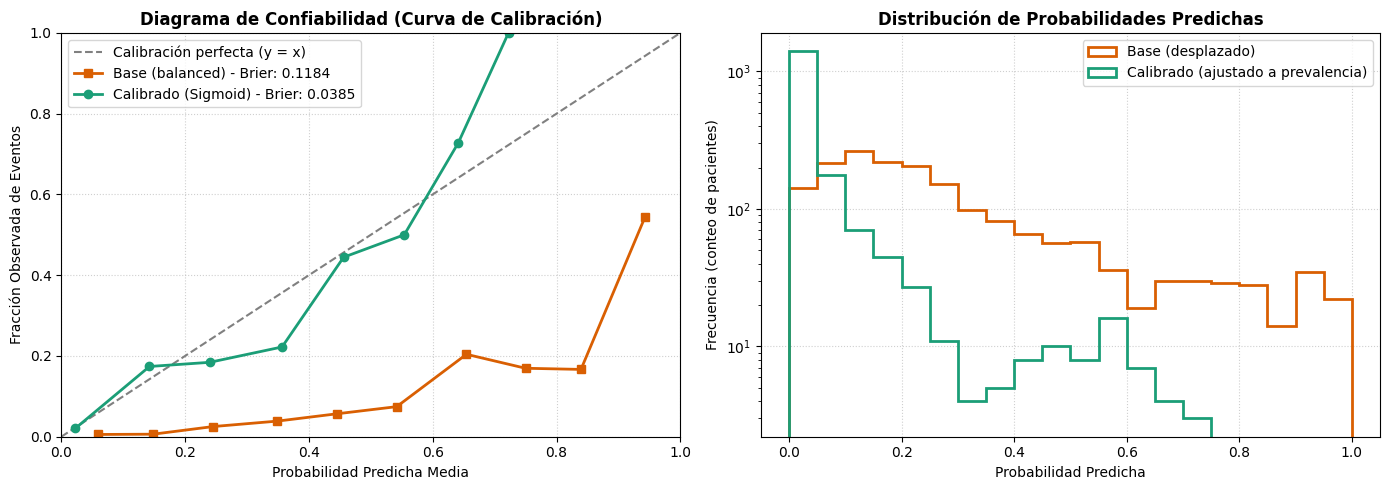

In [11]:
# ==============================================================================
# CELDA COMPLEMENTARIA 1: Diagramas de Confiabilidad y Distribución de Scores
# ==============================================================================

# Cálculo de las curvas de calibración (10 intervalos por cuantiles/uniforme)
frac_pos_base, mean_pred_base = calibration_curve(y_test, probs_raw, n_bins=10, strategy='uniform')
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, probs_cal, n_bins=10, strategy='uniform')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Diagrama de Confiabilidad
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración perfecta (y = x)')
axes[0].plot(mean_pred_base, frac_pos_base, marker='s', linewidth=2, color='#d95f02', 
             label=f'Base (balanced) - Brier: {brier_score_loss(y_test, probs_raw):.4f}')
axes[0].plot(mean_pred_cal, frac_pos_cal, marker='o', linewidth=2, color='#1b9e77', 
             label=f'Calibrado (Sigmoid) - Brier: {brier_score_loss(y_test, probs_cal):.4f}')

axes[0].set_title('Diagrama de Confiabilidad (Curva de Calibración)', fontweight='bold')
axes[0].set_xlabel('Probabilidad Predicha Media')
axes[0].set_ylabel('Fracción Observada de Eventos')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.0])
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', frameon=True)

# 2. Histograma de densidades de probabilidad predicha
axes[1].hist(probs_raw, range=(0, 1), bins=20, histtype='step', lw=2, color='#d95f02', label='Base (desplazado)')
axes[1].hist(probs_cal, range=(0, 1), bins=20, histtype='step', lw=2, color='#1b9e77', label='Calibrado (ajustado a prevalencia)')
axes[1].set_title('Distribución de Probabilidades Predichas', fontweight='bold')
axes[1].set_xlabel('Probabilidad Predicha')
axes[1].set_ylabel('Frecuencia (conteo de pacientes)')
axes[1].set_yscale('log') # Escala logarítmica para visualizar el desbalance extremo
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

In [10]:
# ==============================================================================
# CELDA COMPLEMENTARIA 2: Análisis del Umbral Operativo bajo Asimetría de Costos
# ==============================================================================
# Discusión pedagógica:
# Al calibrar el modelo, predecir con el umbral estándar tau = 0.5 colapsa el recall
# (de 0.70 a 0.25) porque los eventos tienen prevalencia de solo 5%.
# En salud, el umbral operativo debe elegirse a partir de la razón de costos clínicos (FN vs FP).

thresholds = [0.05, 0.10, 0.20, 0.30, 0.50]
eval_thresholds = []

for t in thresholds:
    preds_t = (probs_cal >= t).astype(int)
    rep = classification_report(y_test, preds_t, output_dict=True, zero_division=0)
    eval_thresholds.append({
        'Umbral (tau)': t,
        'Precision (Clase 1)': rep['1']['precision'],
        'Recall / Sensibilidad (Clase 1)': rep['1']['recall'],
        'F1-Score (Clase 1)': rep['1']['f1-score'],
        'Total Alertas Generadas': int(preds_t.sum())
    })

df_thresholds = pd.DataFrame(eval_thresholds)
print("=== COMPORTAMIENTO SEGÚN EL UMBRAL CLÍNICO (MODELO CALIBRADO) ===")
print(df_thresholds.to_string(index=False))

=== COMPORTAMIENTO SEGÚN EL UMBRAL CLÍNICO (MODELO CALIBRADO) ===
 Umbral (tau)  Precision (Clase 1)  Recall / Sensibilidad (Clase 1)  F1-Score (Clase 1)  Total Alertas Generadas
         0.05             0.182278                         0.774194            0.295082                      395
         0.10             0.275229                         0.645161            0.385852                      218
         0.20             0.388350                         0.430108            0.408163                      103
         0.30             0.507692                         0.354839            0.417722                       65
         0.50             0.605263                         0.247312            0.351145                       38
